HOUSE PRICE PREDICTION

Import necessary libraries for vizualization and doing operations.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

Import dataset.

In [3]:
df = pd.read_csv('../data/housing.csv')

First view at our train data. EDA


In [ ]:
print("First 5 rows of data: ")
display(df.head())

print("\nInformation about data: ")
df.info()

print("\nStatistics: ")
display(df.describe())

First 5 rows of data: 


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,rooms_per_household,bedrooms_per_room,population_per_household
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND,5.045455,0.224625,2.560606
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND,6.114035,0.215208,3.122807
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND,5.205543,0.215173,2.325635
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND,5.329513,0.219892,2.123209
20639,-121.24,39.37,16.0,2785.0,616.0,1387.0,530.0,2.3886,89400.0,INLAND,5.254717,0.221185,2.616981



Information about data: 
<class 'pandas.core.frame.DataFrame'>
Index: 20433 entries, 0 to 20639
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   longitude                 20433 non-null  float64
 1   latitude                  20433 non-null  float64
 2   housing_median_age        20433 non-null  float64
 3   total_rooms               20433 non-null  float64
 4   total_bedrooms            20433 non-null  float64
 5   population                20433 non-null  float64
 6   households                20433 non-null  float64
 7   median_income             20433 non-null  float64
 8   median_house_value        20433 non-null  float64
 9   ocean_proximity           20433 non-null  object 
 10  rooms_per_household       20433 non-null  float64
 11  bedrooms_per_room         20433 non-null  float64
 12  population_per_household  20433 non-null  float64
dtypes: float64(12), object(1)
memory usage: 

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,rooms_per_household,bedrooms_per_room,population_per_household
count,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000
mean,-119.570689,35.633221,28.633094,2636.504233,537.870553,1424.946949,499.433465,3.871162,206864.413155,5.431344,0.213039,3.071533
std,2.003578,2.136348,12.591805,2185.269567,421.385070,1133.208490,382.299226,1.899291,115435.667099,2.482946,0.057983,10.438269
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000,0.846154,0.100000,0.692308
25%,-121.800000,33.930000,18.000000,1450.000000,296.000000,787.000000,280.000000,2.563700,119500.000000,4.441441,0.175427,2.429032
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.536500,179700.000000,5.230769,0.203162,2.817582
75%,-118.010000,37.720000,37.000000,3143.000000,647.000000,1722.000000,604.000000,4.744000,264700.000000,6.052381,0.239821,3.281513
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000,141.909091,1.000000,1243.333333


Let`s get the information from type='object'

In [5]:
df.describe(include=['object'])

,ocean_proximity
count,20640
unique,5
top,<1H OCEAN
freq,9136


Conclusion:  Dataset contains 20640 records. We have a mix of numerical features and one categorical feature (ocean_proximity). A significant number of missing values ​​were found in the total_bedrooms column (~1%). It is advisable to remove 207 rows from each column except from column "total bedrooms".

In [6]:
#
# median_bedrooms = df['total_bedrooms'].median()
#df['total_bedrooms'] = df['total_bedrooms'].fillna(median_bedrooms)
df.dropna(subset=['total_bedrooms'], inplace=True)

In [7]:
#from sklearn.model_selection import train_test_split

#X = df.drop(
#    ['median_house_value'], 
#    axis=1
#    )
#y = df["median_house_value"]

#print("Features (X): ")
#display(X.head())

#print("Target (y): ")
#display(y.head())

# І тільки потім запускаємо обробку (Imputer, Scaler тощо)
# X_prepared = my_pipeline.fit_transform(X)

#X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [8]:
#visual_data = X_train.copy()
#visual_data['median_house_value'] = y_train


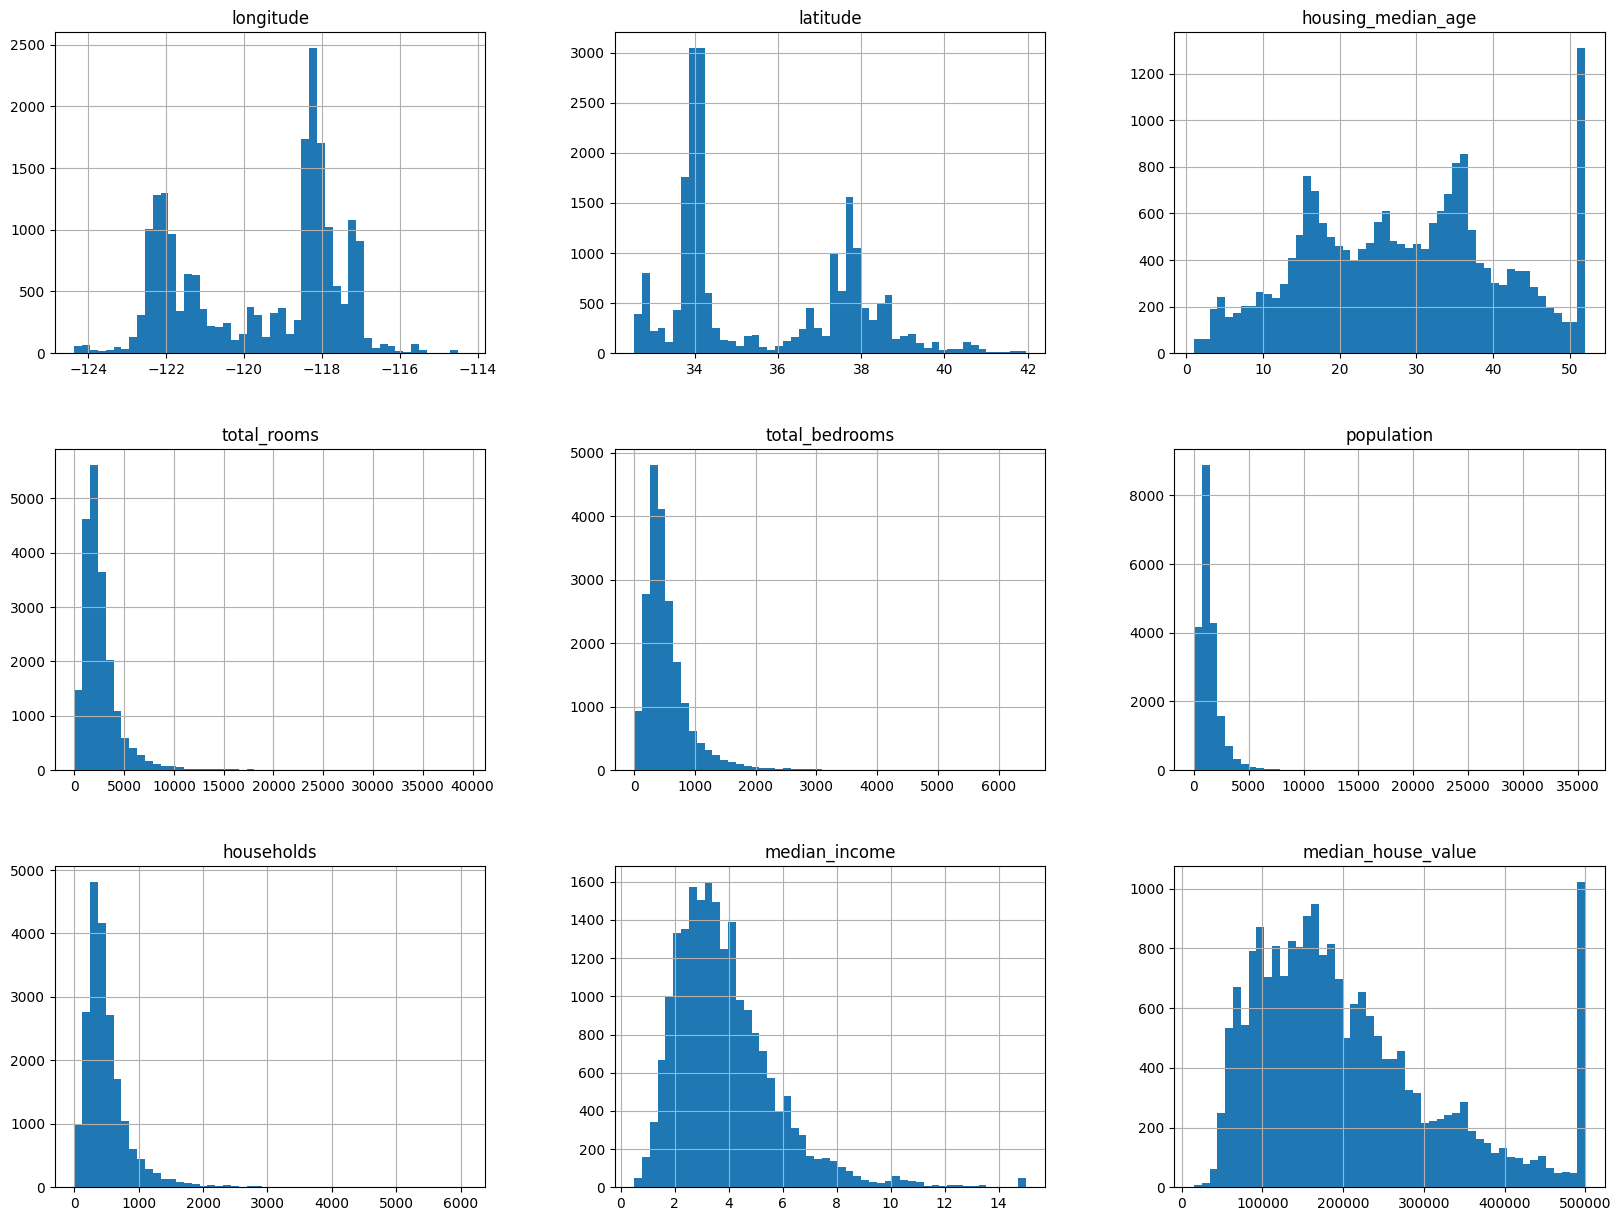

In [9]:
df.hist(bins=50, figsize=(20, 15))
plt.show()

Дивлячиьс на дані гістограми можна побачити декілька штук які можна змінити 1. scaling 2 обрізані дані у housing_med age and median house val 3 нечашоподібні 4 ті ознаки 4 створення нових ознак

<Axes: xlabel='longitude', ylabel='latitude'>

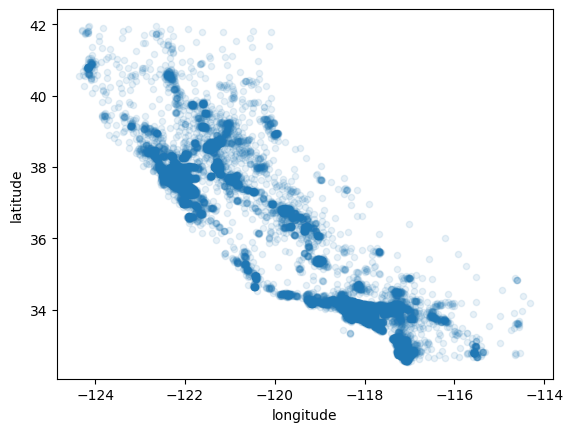

In [10]:
df.plot(kind="scatter", x="longitude", y="latitude",alpha=0.1)

по цьому графку ми можемо побачити що найбільша щільність даних є в там де Лос-Анджелес і Сан - Франциско. Також можна проаналізувати що більшість даних розташованих вздовж узбережжя а центральна частина заселена набагто менше.Щоб графік був більші інформативнимм добавимо ще дві ознаки ціна та наседеггя.

<Axes: xlabel='longitude', ylabel='latitude'>

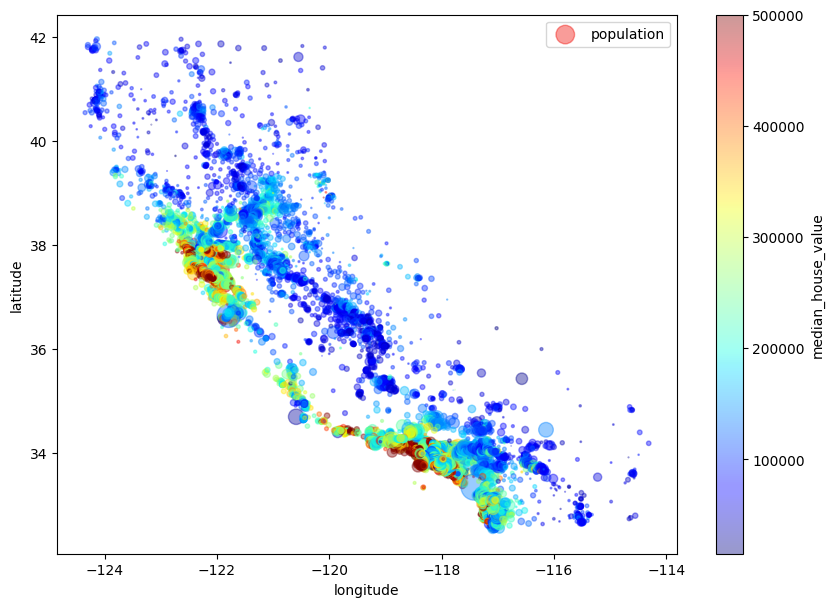

In [11]:
df.plot(
    kind="scatter",
    x="longitude",
    y="latitude",
    alpha=0.4,
    s=df["population"]/100,
    label="population",
    c="median_house_value",
    cmap="jet",
    colorbar=True,
    figsize=(10, 7),
    sharex=False
)

можна проаналізувати що нацдорожче житло зосереджене саме вздовж берегової лінії. Також ціна дуж стльно корелює з конкретними коопдинатаит та близькістю до великих міст.

In [12]:
corr_matrix = df.corr(numeric_only=True)
corr_matrix["median_house_value"].sort_values(ascending=False)

median_house_value    1.000000
median_income         0.688355
total_rooms           0.133294
housing_median_age    0.106432
households            0.064894
total_bedrooms        0.049686
population           -0.025300
longitude            -0.045398
latitude             -0.144638
Name: median_house_value, dtype: float64

Бачимо що найбільше корелює з вартістю будинку це заррплата що є важливим бачимо що кількість кімнати мало впливає на вартість житла. цу може бути бо воно рахує загальну кількість кімнат у районі або це може бути якийсь гуртожиток. тому зроблю нові ознаки як кількість кімнат в одному будинку, відношення спалень до загальних кімнат і скільки людей проживає в однім житлі оскільки хочу дізнатись як вони корелюють з вартістю. хоч локація і відємна але за критерієм пірсона можна сказати що це + а отже є важливими досить.


Feature engineering

In [13]:
df["rooms_per_household"] = df["total_rooms"] / df["households"]
df["bedrooms_per_room"] = df["total_bedrooms"] / df["total_rooms"]
df["population_per_household"] = df["population"] / df["households"]

corr_matrix = df.corr(numeric_only=True)

print(corr_matrix["median_house_value"].sort_values(ascending=False))

median_house_value          1.000000
median_income               0.688355
rooms_per_household         0.151344
total_rooms                 0.133294
housing_median_age          0.106432
households                  0.064894
total_bedrooms              0.049686
population_per_household   -0.023639
population                 -0.025300
longitude                  -0.045398
latitude                   -0.144638
bedrooms_per_room          -0.255880
Name: median_house_value, dtype: float64


бачимо що відношення віталень до загальної кількості кімнат має другу за силою кореляцію після доходу, тому дає більше ефективності. була покращена rooms_per_household є чистішим показнникомю

In [14]:
df.drop(['total_bedrooms', 'population', 'population_per_household', 'total_rooms', 'households'], axis=1)

,longitude,latitude,housing_median_age,median_income,median_house_value,ocean_proximity,rooms_per_household,bedrooms_per_room
0,-122.23,37.88,41.0,8.3252,452600.0,NEAR BAY,6.984127,0.146591
1,-122.22,37.86,21.0,8.3014,358500.0,NEAR BAY,6.238137,0.155797
2,-122.24,37.85,52.0,7.2574,352100.0,NEAR BAY,8.288136,0.129516
3,-122.25,37.85,52.0,5.6431,341300.0,NEAR BAY,5.817352,0.184458
4,-122.25,37.85,52.0,3.8462,342200.0,NEAR BAY,6.281853,0.172096
...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1.5603,78100.0,INLAND,5.045455,0.224625
20636,-121.21,39.49,18.0,2.5568,77100.0,INLAND,6.114035,0.215208
20637,-121.22,39.43,17.0,1.7000,92300.0,INLAND,5.205543,0.215173
20638,-121.32,39.43,18.0,1.8672,84700.0,INLAND,5.329513,0.219892


array([[<Axes: xlabel='median_house_value', ylabel='median_house_value'>,
        <Axes: xlabel='median_income', ylabel='median_house_value'>,
        <Axes: xlabel='total_rooms', ylabel='median_house_value'>,
        <Axes: xlabel='housing_median_age', ylabel='median_house_value'>],
       [<Axes: xlabel='median_house_value', ylabel='median_income'>,
        <Axes: xlabel='median_income', ylabel='median_income'>,
        <Axes: xlabel='total_rooms', ylabel='median_income'>,
        <Axes: xlabel='housing_median_age', ylabel='median_income'>],
       [<Axes: xlabel='median_house_value', ylabel='total_rooms'>,
        <Axes: xlabel='median_income', ylabel='total_rooms'>,
        <Axes: xlabel='total_rooms', ylabel='total_rooms'>,
        <Axes: xlabel='housing_median_age', ylabel='total_rooms'>],
       [<Axes: xlabel='median_house_value', ylabel='housing_median_age'>,
        <Axes: xlabel='median_income', ylabel='housing_median_age'>,
        <Axes: xlabel='total_rooms', ylabel='housi

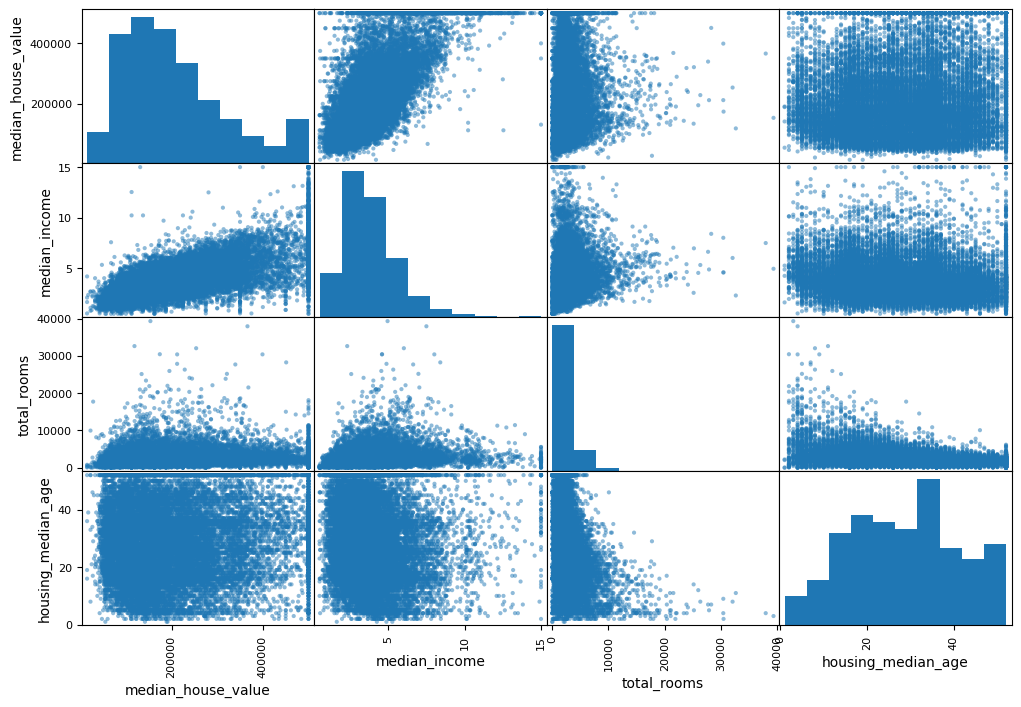

In [15]:
from pandas.plotting import scatter_matrix

attributes = ["median_house_value", "median_income", "total_rooms", "housing_median_age"]
scatter_matrix(df[attributes], figsize=(12, 8))

In [16]:
df["ocean_proximity"].value_counts()

ocean_proximity
<1H OCEAN     9034
INLAND        6496
NEAR OCEAN    2628
NEAR BAY      2270
ISLAND           5
Name: count, dtype: int64

In [17]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
#print(num_attribs)

X = df.drop("median_house_value", axis=1)
y = df["median_house_value"].copy()


num_attribs = list(X.drop("ocean_proximity", axis=1).columns)

cat_attribs = ["ocean_proximity"]

full_pipeline = ColumnTransformer([
    ("num",          StandardScaler(),       num_attribs),
    ("cat",          OneHotEncoder(),        cat_attribs),
])

X_prepared = full_pipeline.fit_transform(X)
#
print(X_prepared.shape)


(20433, 16)


In [18]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_prepared, y, test_size=0.2)

Linear Regression

In [19]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score

lin_reg_model = LinearRegression()

scores = cross_val_score(
    lin_reg_model, 
    X_train, 
    y_train,
    scoring="neg_mean_squared_error",
    cv=10)

rmse_scores = np.sqrt(-scores)

def display_scores(scores):
    print("Scores:", scores)
    print("Mean:", scores.mean())
    print("Standard deviation:", scores.std())

display_scores(rmse_scores)

Scores: [68100.17151705 70088.52631643 68338.21603637 67366.65630084
 68297.13996984 69148.44792581 66707.32394996 67007.20179721
 70632.04002308 68215.76834314]
Mean: 68390.14921797425
Standard deviation: 1200.141733951226


Ця модель миає недонавчання!

Decisison Tree

In [20]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error

# 1. Створюємо і вчимо модель
tree_reg = DecisionTreeRegressor(random_state=42)
tree_reg.fit(X_train, y_train)

# 2. Робимо прогноз на тих самих даних, на яких вчилися
housing_predictions = tree_reg.predict(X_train)

# 3. Рахуємо помилку
tree_mse = mean_squared_error(y_train, housing_predictions)
tree_rmse = np.sqrt(tree_mse)
print(tree_rmse)

scores = cross_val_score(
    tree_reg, 
    X_train, 
    y_train,
    scoring="neg_mean_squared_error", 
    cv=10)

tree_rmse_scores = np.sqrt(-scores)

print("🌲 Результати Дерева:")
display_scores(tree_rmse_scores)

0.0
🌲 Результати Дерева:
Scores: [72943.28236713 77129.03937585 70381.09064257 70050.73189444
 69976.16815399 68814.62498561 70430.14227704 72582.00903156
 70044.22735209 70576.16004277]
Mean: 71292.74761230462
Standard deviation: 2269.6551451609344


ми побачили 0 але це зразу видно ознаку перенавчання. дерево настільки гнучке що запамятало кожен будинок у тренувальному наборі. тому показав гірші результати ніж лінійна регресія. тому мною було прийнято рішення провести тюннг гіперпараметрів

Tuned Decision tree

In [21]:
from sklearn.model_selection import GridSearchCV

param_grid_tree = [
    {'max_depth': [None, 5, 10, 15], 'min_samples_leaf': [1, 5, 10, 20], 'max_features': [2, 4, 6, 8]}
]

tree_reg = DecisionTreeRegressor(random_state=42)

grid_search = GridSearchCV(tree_reg, param_grid_tree, cv=5, scoring="neg_mean_squared_error", return_train_score=True)

grid_search.fit(X_train, y_train)

print("Найкращі параметри:", grid_search.best_params_)

best_tree_rmse = np.sqrt(-grid_search.best_score_)
print(f"Найкраща помилка (RMSE) тюнінгованого дерева: ${best_tree_rmse:.2f}")

Найкращі параметри: {'max_depth': 15, 'max_features': 8, 'min_samples_leaf': 20}
Найкраща помилка (RMSE) тюнінгованого дерева: $60022.01


Random forest classifier

In [22]:
from sklearn.ensemble import RandomForestRegressor
forest_reg = RandomForestRegressor(n_estimators=100, random_state=42)

forest_scores = cross_val_score(forest_reg, X_train, y_train,
                                scoring="neg_mean_squared_error", cv=10)

forest_rmse_scores = np.sqrt(-forest_scores)

print("🌲🌲🌲 Результати Випадкового Лісу:")
display_scores(forest_rmse_scores)

🌲🌲🌲 Результати Випадкового Лісу:
Scores: [49861.81730891 53024.99858308 50624.99861356 50343.07872953
 49449.3355543  51005.70337532 50317.12457872 49047.12254789
 50120.93677781 49263.38862033]
Mean: 50305.850468945355
Standard deviation: 1078.1014863538076


Tuned

In [23]:
param_grid = [
    {'n_estimators': [3, 10, 30], 'max_features': [2, 4, 6, 8]},
    {'bootstrap': [False], 'n_estimators': [3, 10], 'max_features': [2, 3, 4]},
]

forest_reg = RandomForestRegressor(random_state=42)

grid_search = GridSearchCV(forest_reg, param_grid, cv=5, scoring="neg_mean_squared_error", return_train_score=True)

grid_search.fit(X_train, y_train)

print("Найкращі параметри:", grid_search.best_score_)

best_random = np.sqrt(-grid_search.best_score_)
print(f"Найкраща помилка (RMSE) тюнінгованого лісу: ${best_random:.2f}")

Найкращі параметри: -2527786706.5607233
Найкраща помилка (RMSE) тюнінгованого лісу: $50277.10


тест

In [24]:

final_model = grid_search.best_estimator_
# 3. Робимо фінальний прогноз
final_predictions = final_model.predict(X_test)

# 4. Рахуємо фінальну помилку (RMSE)
final_mse = mean_squared_error(y_test, final_predictions)
final_rmse = np.sqrt(final_mse)

print(f"🏁 Фінальна помилка на тесті: ${final_rmse:.2f}")

🏁 Фінальна помилка на тесті: $47316.40


In [25]:
#
feature_importances = final_model.feature_importances_

# 3. Витягуємо назви категорій океану (бо вони були сховані в OneHotEncoder)
cat_encoder = full_pipeline.named_transformers_["cat"]
cat_one_hot_attribs = list(cat_encoder.categories_[0])

# 4. З'єднуємо всі назви разом (числові + океан)
attributes = num_attribs + cat_one_hot_attribs

# 5. Сортуємо і виводимо красиво
sorted_importances = sorted(zip(feature_importances, attributes), reverse=True)

for importance, name in sorted_importances:
    print(f"{name}: {importance:.4f}")

    

median_income: 0.3335
INLAND: 0.1400
population_per_household: 0.1002
bedrooms_per_room: 0.0904
longitude: 0.0778
latitude: 0.0694
rooms_per_household: 0.0471
housing_median_age: 0.0432
total_bedrooms: 0.0177
total_rooms: 0.0176
population: 0.0175
<1H OCEAN: 0.0175
households: 0.0162
NEAR OCEAN: 0.0073
NEAR BAY: 0.0046
ISLAND: 0.0001


In [26]:
import joblib

joblib.dump(full_pipeline, "full_pipeline.pkl")

joblib.dump(final_model, "final_model.pkl")


['final_model.pkl']